# **TITANIC DATASET**

The sinking of the RMS Titanic stands as one of the most well-known maritime disasters in history. On April 15, 1912, during its maiden voyage, the ship struck an iceberg and sank, resulting in the deaths of 1,502 of the 2,224 passengers and crew on board. Although chance played a role in survival, the outcomes were not purely random; certain groups had a higher likelihood of surviving than others.

**Objective:**

The purpose of this project is to develop a Machine Learning model capable of predicting passenger survival in the Titanic disaster. Rather than limiting the analysis to basic data inspection, this work focuses on building a comprehensive end-to-end engineering pipeline.

**Methodology:**

The project follows a systematic workflow that includes:

`Exploratory Data Analysis (EDA):` Examining relationships among key variables such as age, passenger class, and gender.

`Feature Engineering:` Deriving new features, including titles extracted from names and family size calculated from relatives on board, to reveal underlying social dynamics.

`Data Cleaning:` Applying sophisticated imputation techniques to address missing values while preserving data reliability.

`Modeling:` Training a Random Forest classifier to capture complex, non-linear survival patterns.

By the conclusion of this study, the goal is to deliver a reliable predictive model capable of accurately classifying previously unseen passenger data.

In [115]:
%pip install kagglehub[pandas-datasets]
%pip install scikit-learn
%pip install matplotlib
%pip install seaborn
%pip install pandas numpy scipy

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# 1. Load train and test data

For this project we got the information from 2 different csv files, one for the train data and the second one for the test data.

So the first thing we have to do is to load them and we are going to show the train data since this is the one we are going to modify.

In [116]:
import pandas as pd

# Cargar los datos
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

In [117]:
# 1. Basic structure
# Checking the total number of rows (passengers) and columns (features)
print("Rows and columns:", train_data.shape)
print("----------------------------------------------------------")

# 2. General check-up (Data types and null values)
# Understanding the metadata to see which variables are numeric or text
print(train_data.info())



Rows and columns: (891, 12)
----------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [118]:
# 3. Count of missing values (Holes in the hull)
# Identifying which columns have gaps that need to be filled (imputed)
print(train_data.isnull().sum())
print("----------------------------------------------------------")

# 4. Ver las primeras filas
print(train_data.head())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
----------------------------------------------------------
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            

For this Dataset we need to take into account the following information so that we get the complete understanding of the information given.

**Variable Notes**

`pclass:` A proxy for socio-economic status (SES)

- 1st = Upper

- 2nd = Middle

- 3rd = Lower


`age`: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5



`sibsp:` The dataset defines family relations in this way

- Sibling = brother, sister, stepbrother, stepsister

- Spouse = husband, wife (mistresses and fiancés were ignored)


`parch:` The dataset defines family relations in this way...

- Parent = mother, father

- Child = daughter, son, stepdaughter, stepson

- Some children travelled only with a nanny, therefore parch=0 for them.

# 2. Information overview 

We have run some codes to get this first insight of the information and with that we got to the following conclusions/observations so we establish the following procedures.

- There are a total of 881 different passengers and 12 different variables we are going to work with.
- We have 3 different types of variables.

    - Int(5)

    - Float(2)

    - Object(5)
- Most of the variables are complete but we have to be careful with the ones that are missing since there is a lot of information that we do not have.
- We also have a first look of the first five passengers on the boat so we know what the information looks like.

For this we are going to classify the data in 3 different groups.

**1. Numerical**

**2. Categorical**

**3. Strings**

**4. Identifier**

## 2.1 Numerical variables

Now that we have taken a look we are going deep into the numerical variables so we get to understand them better.

This first step consist in getting some numeric information from the variables that python considers as numerical data, but we are just going to work with `Age`, `SibSp`, `Parch` and `Fare`

In [119]:
# 3. Statistical summary (Vital signs)
# Viewing the mean, min, max, and quartiles of numerical data
print(train_data.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


Now we have a new table that is going to give us more information about the numerical data. These columns are:

* Count: How many data points in that column are not empty.

* Mean: The arithmetic mean.

* Standard Deviation: Measures how “scattered” the data is.

* min: The smallest value found. 

* Quartiles: This is key to understanding the distribution of the data in percentages.

* max: The highest value found.


### 2.1.1 Age

The first variable we are going to analyze is `Age`. 
An important thing to say here its that we have 177 missing values so we'll need to work on that later.

Therefore we have the following table which is going to show us the mos frequent values for this variable.

In [120]:
# Detailed summary of Age
# Using .describe() to see the distribution and .value_counts() for frequencies
print("\n--- Age Value Counts (Top 10) ---")
print(train_data['Age'].value_counts().head(10))


--- Age Value Counts (Top 10) ---
Age
24.0    30
22.0    27
18.0    26
28.0    25
30.0    25
19.0    25
21.0    24
25.0    23
36.0    22
29.0    20
Name: count, dtype: int64


But not only that. We also have the following graphics to show how the information is distributed and to know where the values are.

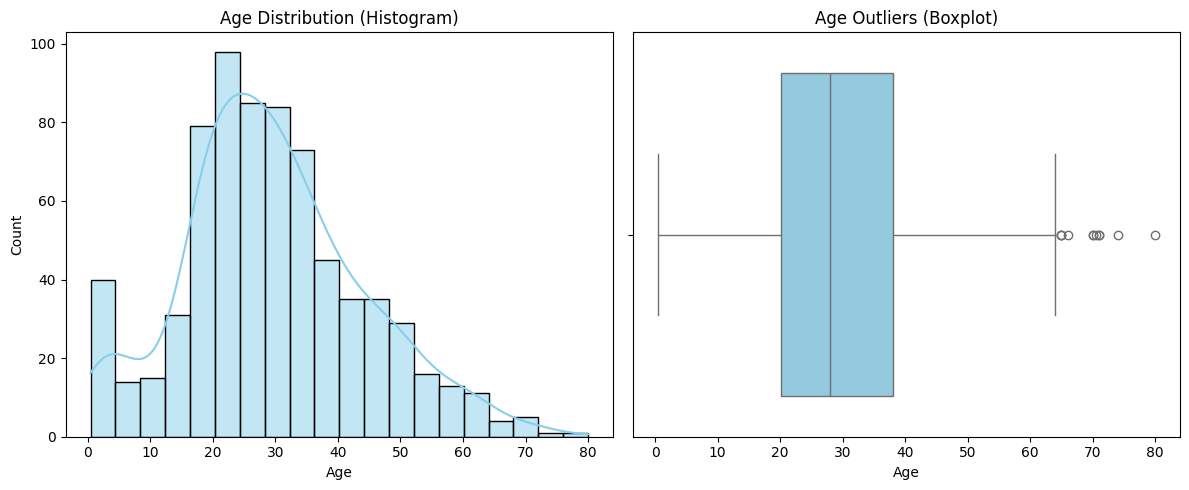

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the figure for two plots side by side
plt.figure(figsize=(12, 5))

# Plot 1: Histogram to see the age distribution
plt.subplot(1, 2, 1)
sns.histplot(train_data['Age'].dropna(), kde=True, color='skyblue')
plt.title('Age Distribution (Histogram)')

# Plot 2: Boxplot to identify extreme ages
plt.subplot(1, 2, 2)
sns.boxplot(x=train_data['Age'], color='skyblue')
plt.title('Age Outliers (Boxplot)')

plt.tight_layout()
plt.show()

With these codes we have gotten a good piece of information which is related to the following.

- As we saw earlier there are `177` missing values, which represents almost 20% of the data, in this variable which will be problematic since the information is incomplete and we'll need to find out how to solve that so the model learns correctly.

- We can also see that the distribution tends to be a "normal distribution" but we can clearly see there is a right skew because of the shape of the curve where the most frequent value is *24 years old* and the mean is some years ahead of it *29 years old* which give us that skew.

- Another thing we need to take into account are the outliers. Since this is a ship that is going to sink the age is a really important fact when we are trying to predict if the passenger survives or not and this is because a *1-year-old* passenger depends on their family to survive, the same applies to an *80-year-old* who most likely need help to move around but the passengers that are near the mean are most likely to have the capacity to move around and escape if necessary.
That's why we need to teach the model that a lower and higher age is important for the prediction because we need to consider the maritime 'women and children first' protocol.


**Bivariate Analysis of Age vs. Survival"**

"Before proceeding with data cleaning or imputation, it is crucial to understand the relationship between Age and the target variable Survived. We perform this analysis at this early stage for two main reasons:

Validation of Imputation Strategy: We need to confirm if children had a higher survival rate. If they did, accurately filling the missing values in the Age column (specifically for titles like 'Master') becomes a priority to maintain model performance.

Feature Engineering Insight: Understanding the distribution shape helps us decide how to segment the data later (e.g., is the cut-off for a 'Child' at 10, 15, or 18 years old?)."

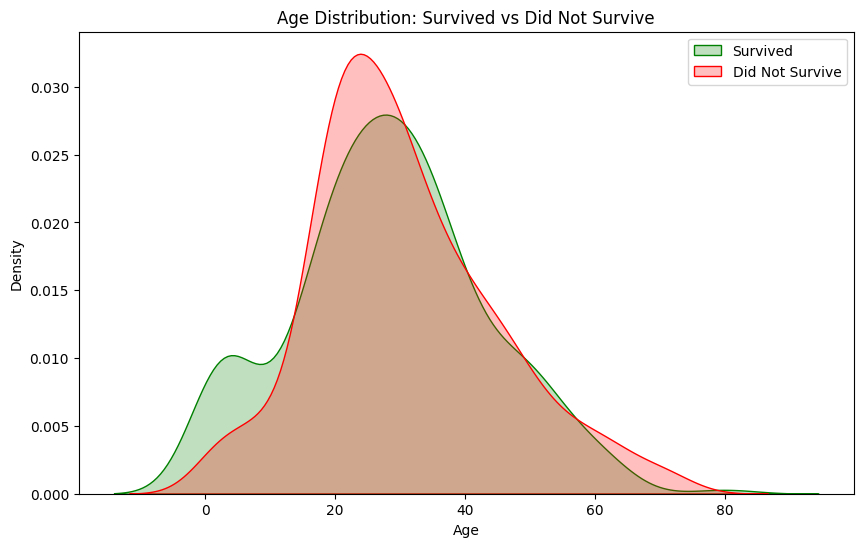

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns  # Corregido: Es 'seaborn', no 'sns'

plt.figure(figsize=(10, 6))

# KDE Plot: Kernel Density Estimate
# This allows us to see the "shape" of the survival distribution by age
sns.kdeplot(data=train_data[train_data['Survived'] == 1]['Age'], label='Survived', fill=True, color='green')
sns.kdeplot(data=train_data[train_data['Survived'] == 0]['Age'], label='Did Not Survive', fill=True, color='red')

plt.title('Age Distribution: Survived vs Did Not Survive')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

**Analysis of the KDE Plot**

"The Kernel Density Estimate (KDE) plot reveals a non-linear relationship between age and survival:

The 'Child' Peak: There is a distinct spike in the green curve (Survivors) for the range of 0 to 10 years old. This confirms the hypothesis that children were given priority during the evacuation, adhering to the maritime 'women and children first' protocol.

The Young Adult Mortality: Conversely, the red curve (Non-Survivors) peaks significantly between 18 and 30 years old, indicating that young adults had a lower probability of survival compared to children.

Conclusion: This visual evidence supports the decision to treat Age not just as a number, but as a categorical indicator of social priority (Child vs. Adult)."

### 2.1.2 SibSp

This is the second variable `SibSp` which might not be so clear what it expresses but the essential information is if the passenger had Siblings and Spouses in the boat. So we are going to see the different values we have on the data.

In [123]:
# Detailed summary of Siblings and Spouses
print("\n--- SibSp Frequency ---")
print(train_data['SibSp'].value_counts())


--- SibSp Frequency ---
SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


As we can see most of the passengers travelled alone so they just have to take care of themselves but there are some families on the boat which represents responsibility  with them.

We also have the following graphics to express this information.

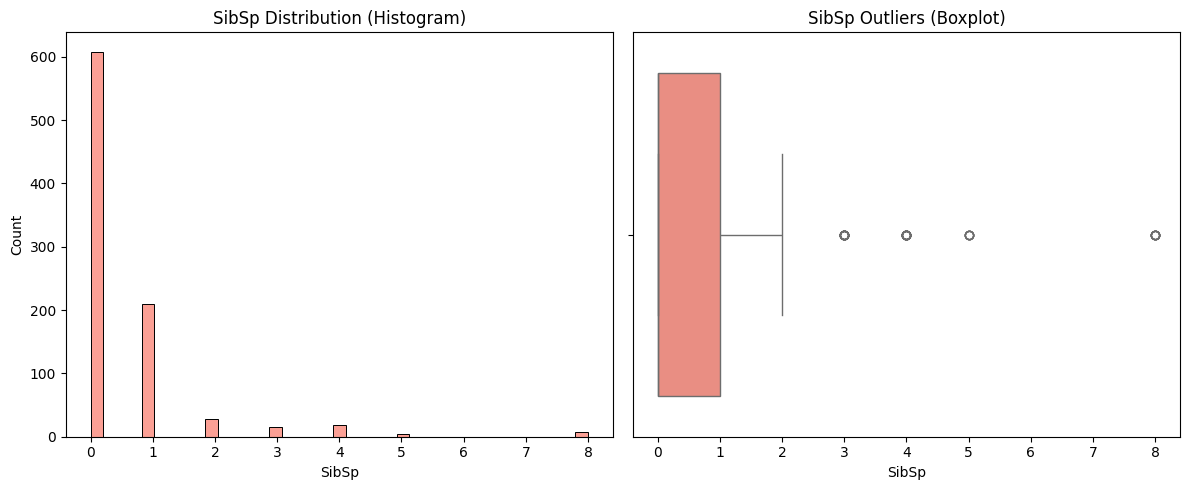

In [124]:
plt.figure(figsize=(12, 5))

# Plot 1: Histogram to see how many people traveled with siblings or spouses
plt.subplot(1, 2, 1)
sns.histplot(train_data['SibSp'], kde=False, color='salmon')
plt.title('SibSp Distribution (Histogram)')

# Plot 2: Boxplot for SibSp
plt.subplot(1, 2, 2)
sns.boxplot(x=train_data['SibSp'], color='salmon')
plt.title('SibSp Outliers (Boxplot)')

plt.tight_layout()
plt.show()

With these codes we have gotten a good piece of information which is related to the following.

- We can clearly see that the distribution of the data presents a right skew since most of the passengers are alone.

- We have those outliers that represents the families on board the ship which it's going to be important at the moment of deciding if the passenger survives or not because it is not the same just to take care of yourself but to take care of other members from the family. According to two different theories, Cooperation Theory and Burden of Care Theory which have influence on the behavior of the model.

**'Family Dynamics' Hypothesis**

The Hypothesis: We propose two conflicting theories. First, the 'Cooperation Theory', where family members help each other reach lifeboats. Second, the 'Burden of Care Theory', where large families struggle to move quickly and refuse to be separated, potentially leading to lower survival rates.

Relevance: Determining which theory dominates allows us to create more effective features later, such as a 'FamilySize' category or an 'IsAlone' indicator, to improve the model's predictions."

C:\Users\User\AppData\Local\Temp\ipykernel_26780\2266254342.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SibSp', y='Survived', data=train_data, palette='magma')


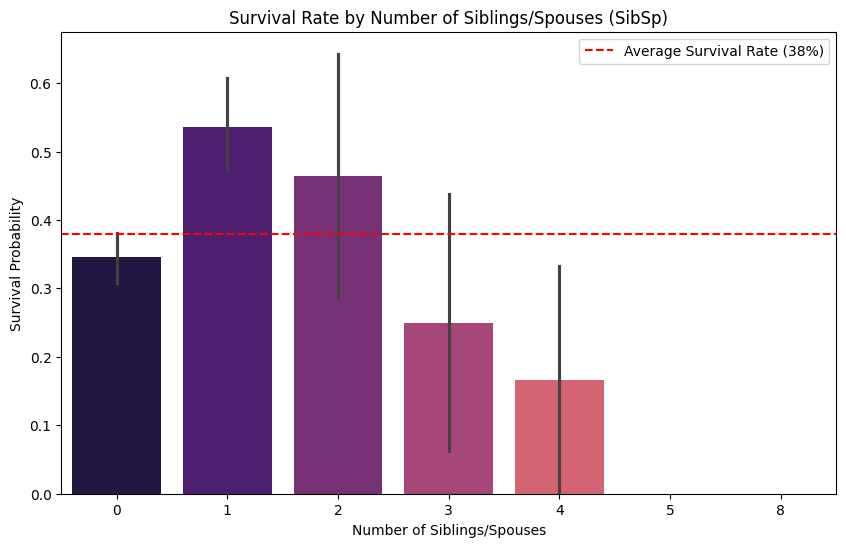

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming train_data is already loaded
# train_data = pd.read_csv('train.csv')

plt.figure(figsize=(10, 6))

# Barplot: Shows the probability of survival for each number of siblings/spouses
# The vertical black lines represent the error margin (confidence interval)
sns.barplot(x='SibSp', y='Survived', data=train_data, palette='magma')

# Visual reference: The average survival rate of the whole ship (38%)
plt.axhline(y=0.38, color='r', linestyle='--', label='Average Survival Rate (38%)')

plt.title('Survival Rate by Number of Siblings/Spouses (SibSp)')
plt.xlabel('Number of Siblings/Spouses')
plt.ylabel('Survival Probability')
plt.legend()

plt.show()

**Analysis of Survival by Sibling/Spouse Count**

"The bar chart reveals a non-linear relationship that supports both theories depending on the family size:

The 'secure Spot' (1-2 Siblings/Spouse): Passengers traveling with a small number of relatives (1 or 2) show the highest survival rates (over 46%), significantly exceeding the ship's average (38%). This suggests that small groups benefited from mutual assistance (cooperation).

The Solo Traveler Penalty (0 Siblings/Spouse): Those traveling alone had a lower survival rate (~34.5%) compared to small families. Lacking a partner to wake them or guide them might have been a disadvantage.

The Large Family Drop-off (3+ Siblings/Spouse): Survival rates plummet as the number of siblings increases. Notably, for families with 5 or 8 siblings, the survival rate drops to 0%. This strongly validates the 'Burden of Care' hypothesis for large groups: the logistical difficulty of keeping a large family together likely proved fatal."

### 2.1.3 Parch

This third variable it's `parch` which stands for parents and children on the boat so we are going to take a look into this one so we get a clear veiw of the complete families that were on the boat.

In [126]:
# Detailed summary of Parents and Children
print("\n--- Parch Frequency ---")
print(train_data['Parch'].value_counts())


--- Parch Frequency ---
Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


Once again most of the passengers were alone with no parents on the boat but some of them do have some of them on the boat which might be interesting to determine if they survived.

We also have the following graphics to show how the information is distributed.

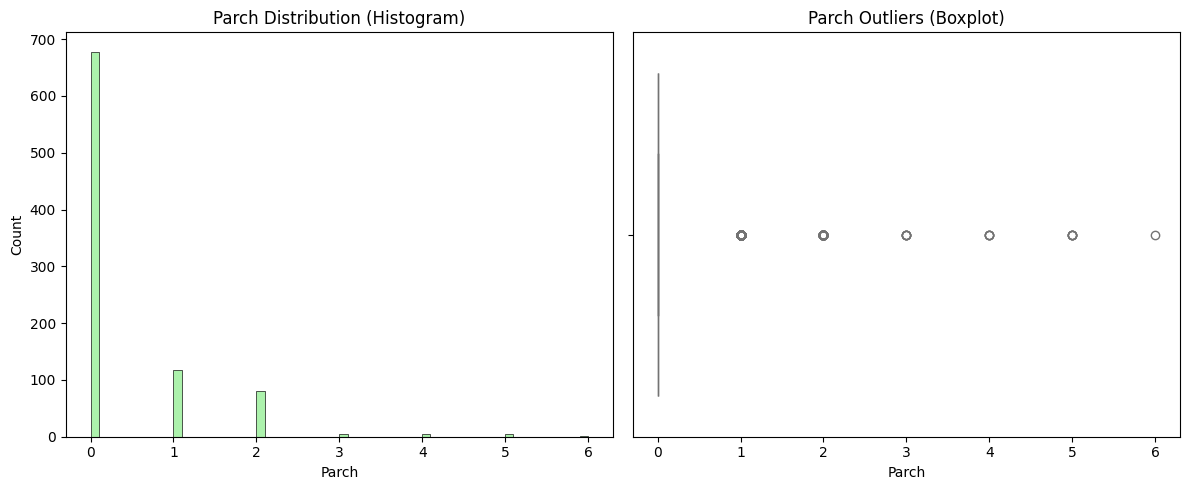

In [127]:
plt.figure(figsize=(12, 5))

# Plot 1: Histogram to see family size (parents/children)
plt.subplot(1, 2, 1)
sns.histplot(train_data['Parch'], kde=False, color='lightgreen')
plt.title('Parch Distribution (Histogram)')

# Plot 2: Boxplot for Parch
plt.subplot(1, 2, 2)
sns.boxplot(x=train_data['Parch'], color='lightgreen')
plt.title('Parch Outliers (Boxplot)')

plt.tight_layout()
plt.show()

With these codes we have gotten a good piece of information which is related to the following.

- The way the data is distributed presents a right skew which let us see that again most of the passengers travelled alone while others have some family members on board

- Once again we have some outliers in the data where some passengers have more than 3 family members on board which once again bring us to two different theories, Cooperation Theory and Burden of Care Theory which have influence on the behavior of the model so we'll need to be aware of that.


**Rationale: Investigating Vertical Family Bonds**

The analysis of the `Parch` variable (Parents and Children) is fundamental to distinguish between different types of family dynamics. While `SibSp` focuses on horizontal relations (siblings/spouses), `Parch` represents the vertical bond between generations.

We perform this analysis to verify if the *Burden of Care* theory applies equally to parents and children. In a crisis, the instinct to protect a child or an elderly parent might lead to different survival outcomes than the bond between siblings. This understanding is key to determining whether we should combine these family variables into a single *Family Size* feature later in the project.

C:\Users\User\AppData\Local\Temp\ipykernel_26780\4196601698.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Parch', y='Survived', data=train_data, palette='viridis')


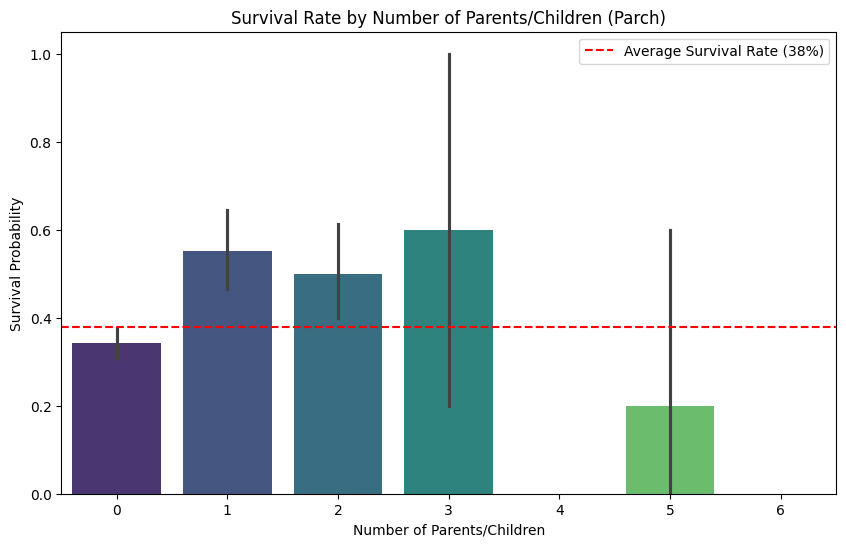

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming train_data is loaded
# train_data = pd.read_csv('train.csv')

plt.figure(figsize=(10, 6))

# Barplot: Survival probability by Parch
sns.barplot(x='Parch', y='Survived', data=train_data, palette='viridis')

# Reference line (Average survival)
plt.axhline(y=0.38, color='r', linestyle='--', label='Average Survival Rate (38%)')

plt.title('Survival Rate by Number of Parents/Children (Parch)')
plt.xlabel('Number of Parents/Children')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()

**Analysis of Survival by Parent/Child Count**

The visual evidence from the bar chart highlights several key patterns:

The Cooperative Peak: Passengers with 1, 2, or 3 parents/children shows the highest survival probabilities (ranging from 50% to 60%). Interestingly, those with 3 family members in this category had a survival rate of 60%, which is even higher than what we observed for siblings. This suggests a very strong *Cooperation Effect* among direct descendants or ancestors.

Solo Travelers (Parch 0): Similar to our previous findings, people traveling without parents or children had a survival rate (~34.4%) below the ship's average.

Large Family Constraints: The *Burden of Care* theory is confirmed for values of 4 or more. Families with 4 or 6 members in this category had a 0% survival rate in this dataset, indicating that the logistical and emotional difficulty of evacuating a large intergenerational group was a critical disadvantage.

### 2.1.4 Fare

The last variable we are going to analyze in this stage is `Fare` which represents the amount of money the passenger paid for the ticket. This might not seem as the most important variable but we'll find out that according to the top ten most common values for this we can get really good information.

In [129]:
# Detailed summary of Ticket Prices
print("\n--- Fare Value Counts (Top 10) ---")
print(train_data['Fare'].value_counts().head(10))


--- Fare Value Counts (Top 10) ---
Fare
8.0500     43
13.0000    42
7.8958     38
7.7500     34
26.0000    31
10.5000    24
7.9250     18
7.7750     16
7.2292     15
26.5500    15
Name: count, dtype: int64


We can see that most of the passengers paid a low cost which means most of the people were concentrated in the same areas in the boat

Apart from that we have the following graphics which show us how the data is distributed and the values we have.

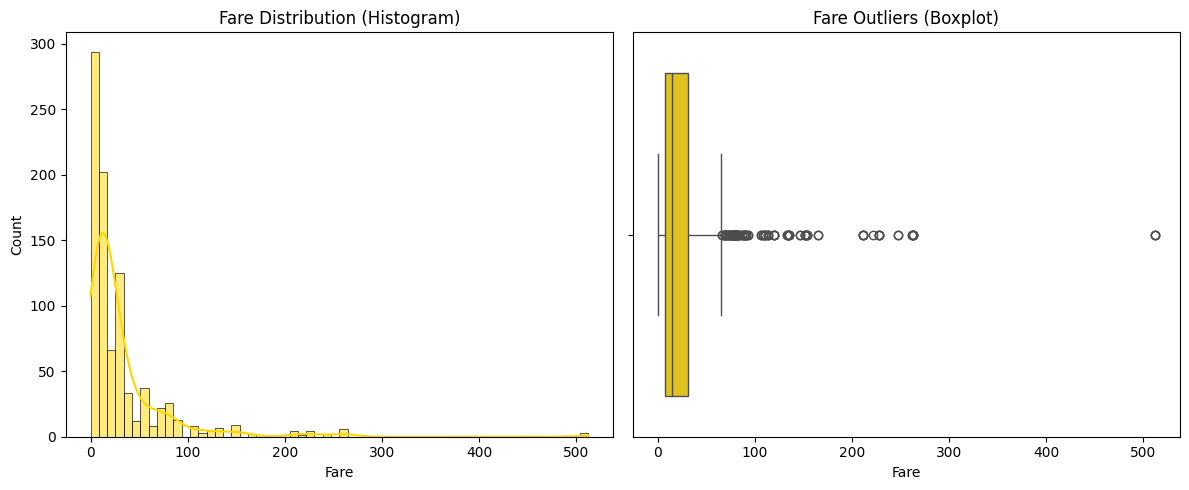

In [130]:
plt.figure(figsize=(12, 5))

# Plot 1: Histogram to see the range of ticket prices
plt.subplot(1, 2, 1)
sns.histplot(train_data['Fare'], kde=True, color='gold')
plt.title('Fare Distribution (Histogram)')

# Plot 2: Boxplot for Fare (Critical for identifying elite passengers)
plt.subplot(1, 2, 2)
sns.boxplot(x=train_data['Fare'], color='gold')
plt.title('Fare Outliers (Boxplot)')

plt.tight_layout()
plt.show()

With these codes we have gotten a good piece of information which is related to the following.

- Once again the data presents a right skew exposing the range and variety of prizes in the boat where we have a really high one but most of them seem to be cheap

- We know that the mean is *32.204208* so those higher prices represented as outliers might be an important factor when deciding if the passenger survives or not since the person who paid *500* most likely it's an important person so he will receive special attention when escaping from the boat but on the other hand those who paid a cheaper ticket won't be treated the same so the model needs to be aware of that when deciding if he survived or not

**Correlation Between Wealth and Survival**

"The Fare variable is one of the most significant numerical features in this classification problem. We present this bivariate analysis to visually confirm the socio-economic bias of the Titanic. By comparing the distribution of ticket prices against the survival outcome, we can determine if the *cost of the ticket* acted as a direct predictor. This is essential for our model because it justifies the use of Fare as a primary feature to distinguish between the two classes (Survived vs. Deceased)."

C:\Users\User\AppData\Local\Temp\ipykernel_26780\1839561482.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=train_data, palette='coolwarm')


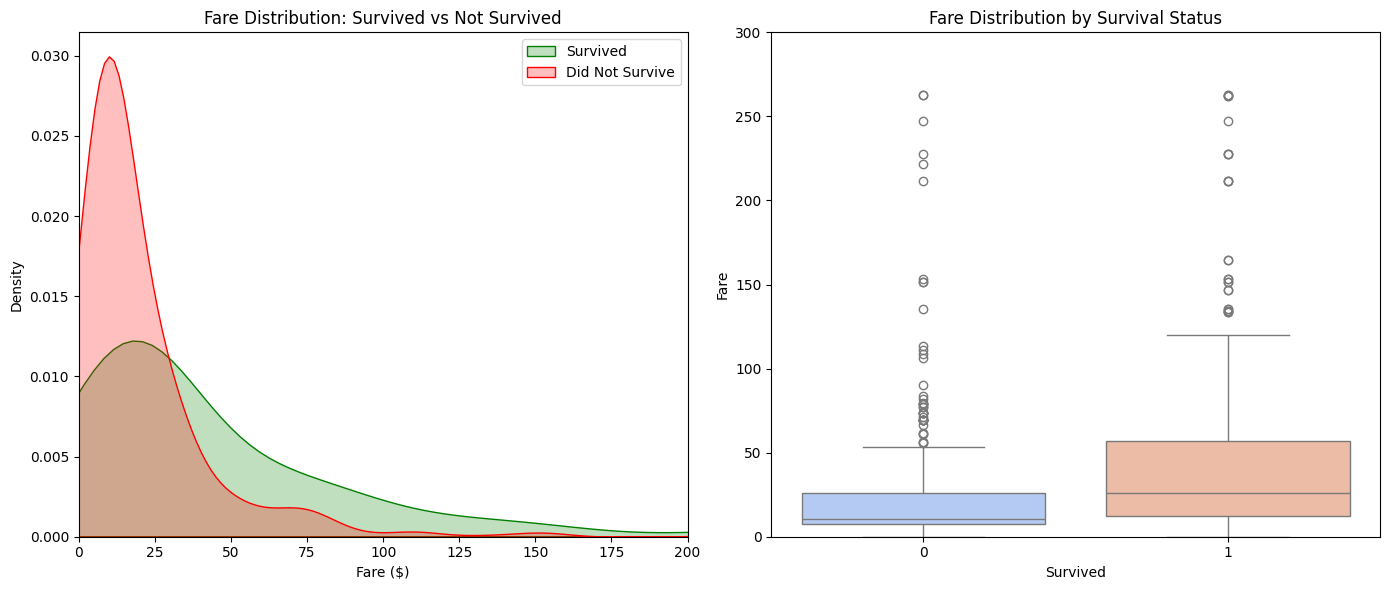

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming train_data is loaded
# We use two plots: KDE for density and Boxplot for outliers
plt.figure(figsize=(14, 6))

# Plot 1: KDE Plot (Zoomed to 0-200 for visibility)
plt.subplot(1, 2, 1)
sns.kdeplot(data=train_data[train_data['Survived'] == 1]['Fare'], label='Survived', fill=True, color='green')
sns.kdeplot(data=train_data[train_data['Survived'] == 0]['Fare'], label='Did Not Survive', fill=True, color='red')
plt.xlim(0, 200) 
plt.title('Fare Distribution: Survived vs Not Survived')
plt.xlabel('Fare ($)')
plt.legend()

# Plot 2: Boxplot (Shows that high fares correlate with Survival)
plt.subplot(1, 2, 2)
sns.boxplot(x='Survived', y='Fare', data=train_data, palette='coolwarm')
plt.ylim(0, 300)
plt.title('Fare Distribution by Survival Status')

plt.tight_layout()
plt.show()

**Observations: The Survival Premium**

The Mortality Peak: The KDE plot shows a massive concentration of non-survivors (red area) at the very low end of the price scale (under $20). This indicates that the majority of those who did not survive paid the cheapest fares.

The Survival Tail: As the fare increases, the green curve (Survivors) stays above the red curve. This confirms that while survivors are fewer in total, they are more prevalent in higher price brackets.

Outlier Impact: The Boxplot reveals that extreme outliers—passengers who paid over $100—have a much higher median survival rate.

Conclusion: There is a clear, positive correlation between the ticket price and the probability of survival. This confirms that Fare is a high-variance feature that will be critical for the classifier’s decision-making process.

## 2.2 Categorical variables


The next group we are going to analyze is the Categorical variables which work as tags or groups for the data categorical variables define the fundamental *segments* of the population. We analyze `Sex`, `Pclass` and `Embarked` to identify if certain groups had an inherent advantage or disadvantage. Unlike numerical data, these variables represent social protocols (like gender priority) or physical locations on the ship (like ticket class)


In [132]:
# Analyzing Categorical Variables one by one
# We use .value_counts() to see the distribution and .describe() for a general overview

categorical_vars = ['Sex', 'Pclass', 'Embarked']

for var in categorical_vars:
    print(f"--- Analysis for Variable: {var} ---")
    
    # .describe() for categorical data shows count, unique categories, and the most frequent one (top)
    print(f"\nSummary Statistics:")
    print(train_data[var].astype(object).describe())
    print("-" * 40)

--- Analysis for Variable: Sex ---

Summary Statistics:
count      891
unique       2
top       male
freq       577
Name: Sex, dtype: object
----------------------------------------
--- Analysis for Variable: Pclass ---

Summary Statistics:
count     891
unique      3
top         3
freq      491
Name: Pclass, dtype: int64
----------------------------------------
--- Analysis for Variable: Embarked ---

Summary Statistics:
count     889
unique      3
top         S
freq      644
Name: Embarked, dtype: object
----------------------------------------


### 2.2.1 Sex

This is the firs variable we are going to analyze in this new group where we are going to try to understand how this one might have affected the survival rate of passengers according to the gender.

In [133]:
# Analyzing Categorical Variables one by one
# We use .value_counts() to see the distribution and .describe() for a general overview

categorical_vars = ['Sex']

for var in categorical_vars:
    print(f"--- Analysis for Variable: {var} ---")
    
    # .value_counts() shows exactly how many passengers are in each "bucket"
    print(f"\nFrequency Counts:")
    print(train_data[var].value_counts())
    
    # Showing percentages is often more useful for the report
    print(f"\nPercentage Distribution:")
    print(train_data[var].value_counts(normalize=True) * 100)

--- Analysis for Variable: Sex ---

Frequency Counts:
Sex
male      577
female    314
Name: count, dtype: int64

Percentage Distribution:
Sex
male      64.758698
female    35.241302
Name: proportion, dtype: float64


For that we have the table which show us the proportions among these 2 gender groups where *male* is on top with 64%. This is a critical insight because, if the 'women first' rule was applied, the majority of the population (men) faced a much higher risk.

But not only that, we also have these graphics to show a complete view of the information.

C:\Users\User\AppData\Local\Temp\ipykernel_26780\1181260284.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=train_data, palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_26780\1181260284.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=train_data, palette='magma')


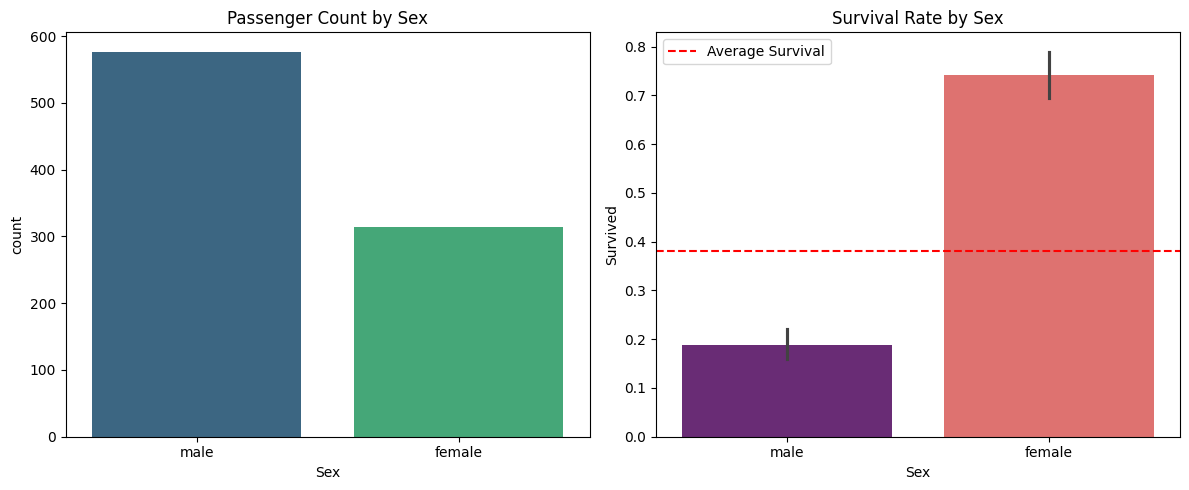

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the frequency and survival rate for Gender
plt.figure(figsize=(12, 5))

# Subplot 1: Count of passengers by sex
plt.subplot(1, 2, 1)
sns.countplot(x='Sex', data=train_data, palette='viridis')
plt.title('Passenger Count by Sex')

# Subplot 2: Probability of survival by sex
plt.subplot(1, 2, 2)
sns.barplot(x='Sex', y='Survived', data=train_data, palette='magma')
plt.axhline(y=0.38, color='r', linestyle='--', label='Average Survival')
plt.title('Survival Rate by Sex')
plt.legend()

plt.tight_layout()
plt.show()

With these codes we got the following information:

- As we mentioned most of the passengers are male, 64% of them actually

- Following the women first rule is in fact a decisive factor when predicting passenger survival as we can see in the second graphic where there is a big difference in the survival rate compared to the original proportions of the data.
So the gender is in fact an important thing to take into account for predicting survival.

### 2.2.2 Pclass

The second variable we are going to work with is `Pclas` which is strongly related to the `Fare` variable, but in this case they are already classfied in different groups 1,2 or 3 according to the price they paid earlier so we are going to go deep into the relationship between them.

In [135]:
# Analyzing Categorical Variables one by one
# We use .value_counts() to see the distribution and .describe() for a general overview

categorical_vars = ['Pclass']

for var in categorical_vars:
    print(f"--- Analysis for Variable: {var} ---")
    
    # .value_counts() shows exactly how many passengers are in each "bucket"
    print(f"\nFrequency Counts:")
    print(train_data[var].value_counts())
    
    # Showing percentages is often more useful for the report
    print(f"\nPercentage Distribution:")
    print(train_data[var].value_counts(normalize=True) * 100)

--- Analysis for Variable: Pclass ---

Frequency Counts:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Percentage Distribution:
Pclass
3    55.106622
1    24.242424
2    20.650954
Name: proportion, dtype: float64


As we mentioned, we have 3 different categories where 1 is the most expensive one and 3 is the most cheaper where we can see that the proportion of cheaper tickets is still there with that big percentage difference.

But not only that, we have the following graphics.

C:\Users\User\AppData\Local\Temp\ipykernel_26780\2615621944.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=train_data, palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_26780\2615621944.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=train_data, palette='magma')


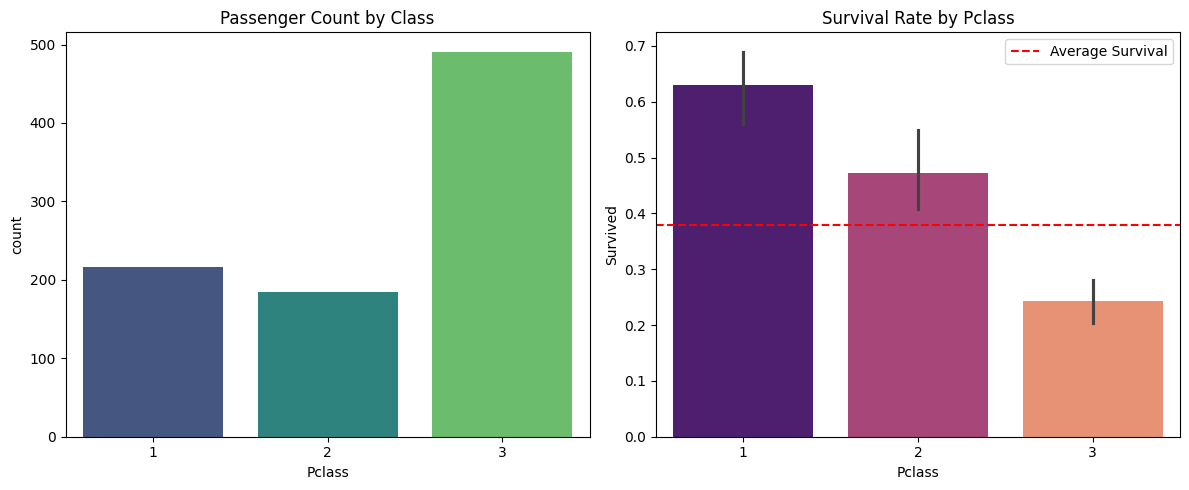

In [136]:
plt.figure(figsize=(12, 5))

# Subplot 1: Count of passengers by class
plt.subplot(1, 2, 1)
sns.countplot(x='Pclass', data=train_data, palette='viridis')
plt.title('Passenger Count by Class')

# Subplot 2: Probability of survival by class
plt.subplot(1, 2, 2)
sns.barplot(x='Pclass', y='Survived', data=train_data, palette='magma')
plt.axhline(y=0.38, color='r', linestyle='--', label='Average Survival')
plt.title('Survival Rate by Pclass')
plt.legend()

plt.tight_layout()
plt.show()

With the information we have analyzed from this variable we can conclude that:

- As mentioned before there is a high difference in the quantity of passengers in the boat according to the price they paid

- We have no outliers since all the information is stratified in 3 groups

- As we predicted earlier in fare, the price which transforms into the Pclass stratification does affect the survival rate, as we can see even though class 1 was only 24% of the data, their survival rate its almost twice the survival rate from class 3 so here we have a strong relationship.

### 2.2.3 Embarked

This is the last variable for this group where we are going to analyze if the port have some influence in the survival rate of the passengers.

Something to take into account is that we have 2 missing values which might not be that important but we need to be aware of that.

In [137]:
# Analyzing Categorical Variables one by one
# We use .value_counts() to see the distribution and .describe() for a general overview

categorical_vars = ['Embarked']

for var in categorical_vars:
    print(f"--- Analysis for Variable: {var} ---")
    
    # .value_counts() shows exactly how many passengers are in each "bucket"
    print(f"\nFrequency Counts:")
    print(train_data[var].value_counts())
    
    # Showing percentages is often more useful for the report
    print(f"\nPercentage Distribution:")
    print(train_data[var].value_counts(normalize=True) * 100)

--- Analysis for Variable: Embarked ---

Frequency Counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Percentage Distribution:
Embarked
S    72.440945
C    18.897638
Q     8.661417
Name: proportion, dtype: float64


As we can see the information is already stratified in 3 different groups which match with the name of the port the passenger embarked where S for Southampton has the most passengers getting on board which is correct since that is the place where the ship departed from meanwhile the others are lower since they incorporated in the middle of the travel.

But we also have the following graphics which shows the information.

C:\Users\User\AppData\Local\Temp\ipykernel_26780\1130160287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Embarked', data=train_data, palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_26780\1130160287.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=train_data, palette='magma')


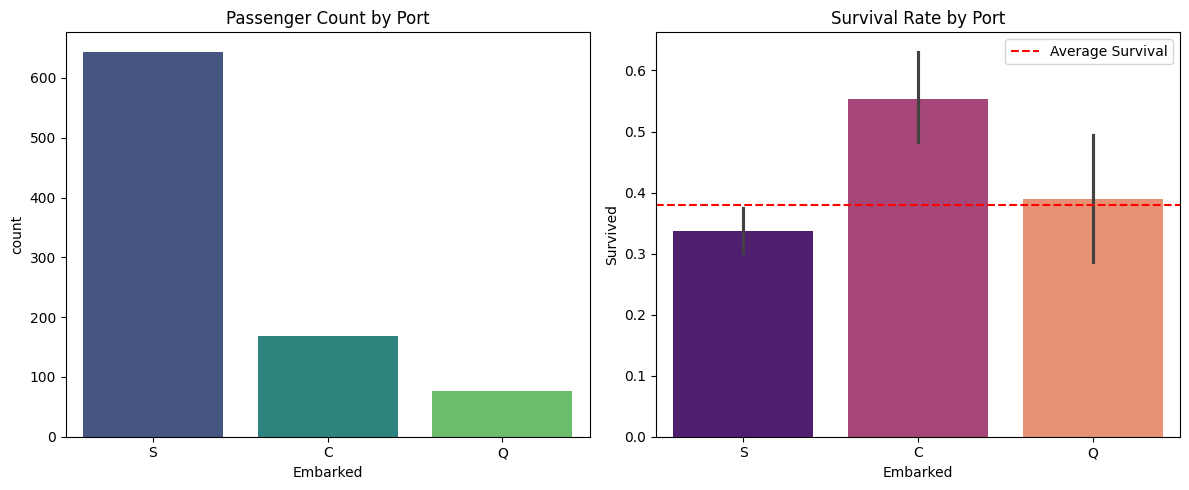

In [138]:
plt.figure(figsize=(12, 5))

# Subplot 1: Count of passengers by port
plt.subplot(1, 2, 1)
sns.countplot(x='Embarked', data=train_data, palette='viridis')
plt.title('Passenger Count by Port')

# Subplot 2: Probability of survival by port
plt.subplot(1, 2, 2)
sns.barplot(x='Embarked', y='Survived', data=train_data, palette='magma')
plt.axhline(y=0.38, color='r', linestyle='--', label='Average Survival')
plt.title('Survival Rate by Port')
plt.legend()

plt.tight_layout()
plt.show()

With the information we have analyzed from this variable we can conclude that:

- We see the high difference of where the passengers embarked with an outstanding 72.4% for S

- The proportions of passengers matter since even though C and Q passengers are a lot less than S passengers that Implicitly raises the quantity of passengers that survived from those places because some of them might have died but according to the Average Survivale many of them have to be alive meanwhile S passengers "follow" the Average survival rule according to the graphic.

**But that is not enough to understand why we have those proportions, therefore we are going to do the following analysis for each group (S,C,Q).**

We are going to check for each group (S,C,Q) and their relationship with the other variables, `Fare`, `Sex`, `Age`, `SibSp` and `Parch` since we have already proved that those variables have a direct impact on survival rate.

--- NUMERICAL SUMMARIES BY PORT (EMBARKED) ---

[1] Fare Mean and Median by Port:
               mean  median
Embarked                   
C         59.954144   29.70
Q         13.276030    7.75
S         27.079812   13.00

[2] Sex Proportion (%) by Port:
Sex          female       male
Embarked                      
C         43.452381  56.547619
Q         46.753247  53.246753
S         31.521739  68.478261

[3] Pclass Proportion (%) by Port:
Pclass            1          2          3
Embarked                                 
C         50.595238  10.119048  39.285714
Q          2.597403   3.896104  93.506494
S         19.720497  25.465839  54.813665


C:\Users\User\AppData\Local\Temp\ipykernel_26780\2521290144.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Embarked', y='Fare', data=train_data, palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_26780\2521290144.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Embarked', y='Age', data=train_data, palette='viridis')


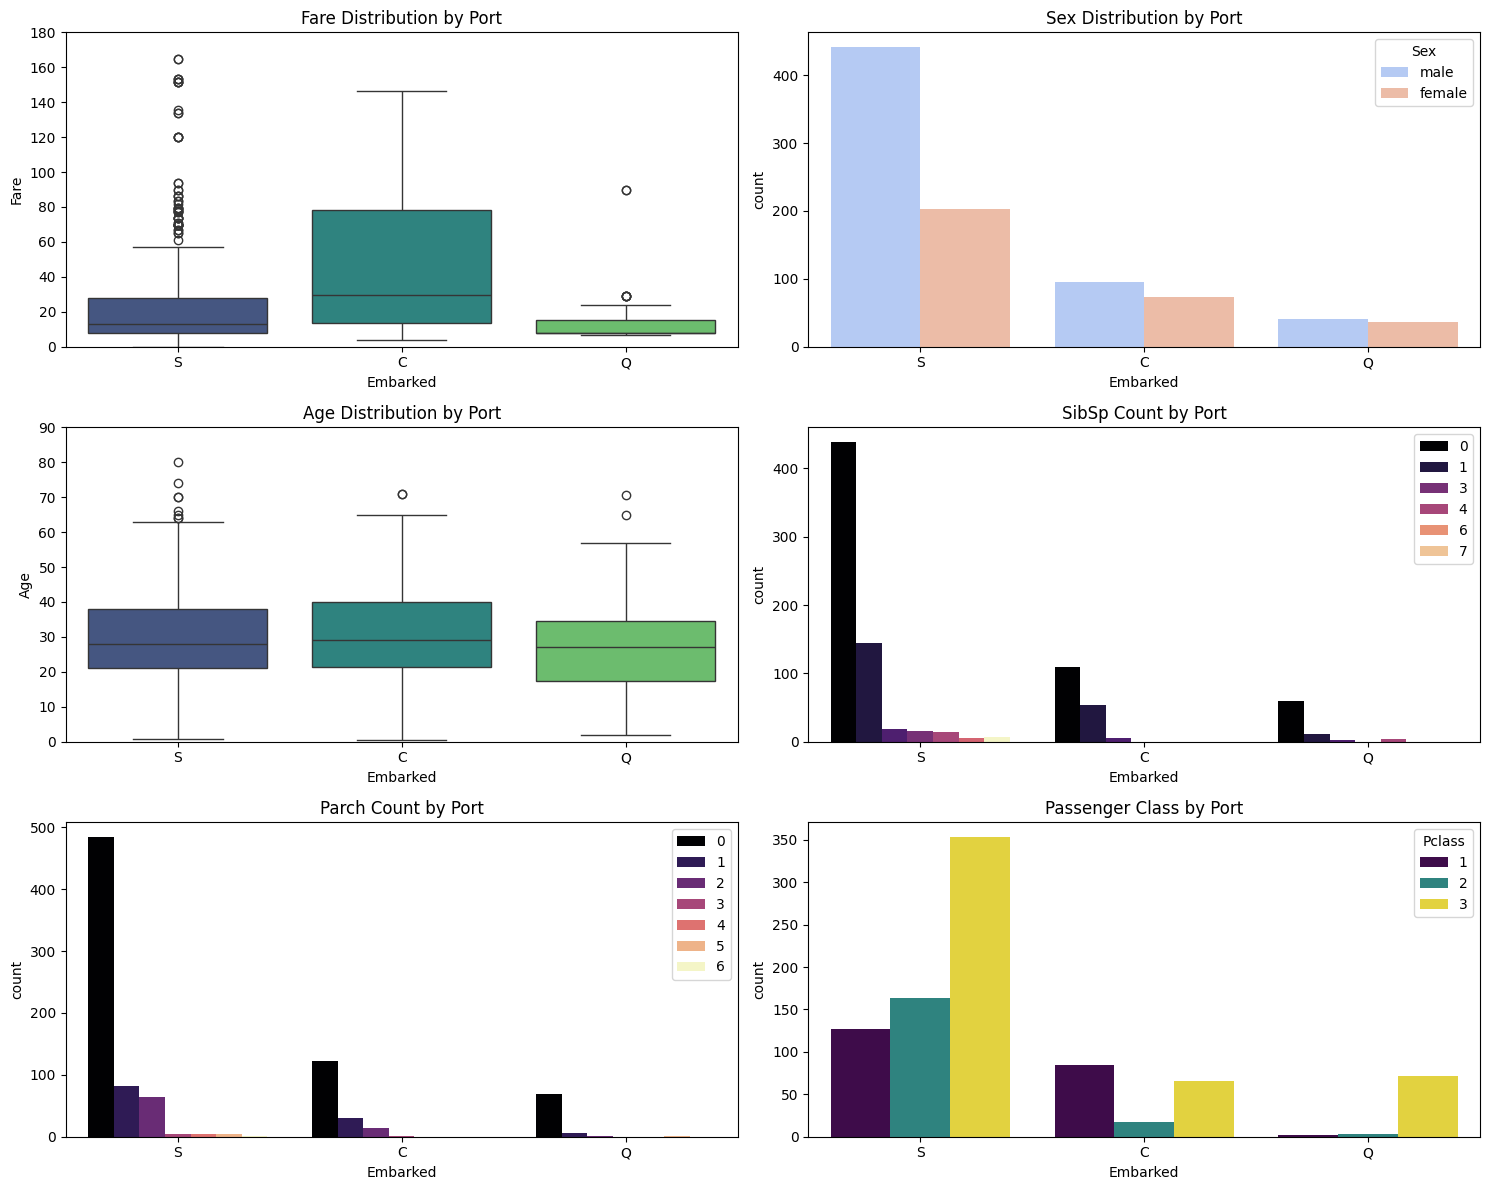

In [139]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Numerical Summaries (The "Math" behind the plots)
print("--- NUMERICAL SUMMARIES BY PORT (EMBARKED) ---")

# Fare stats: Confirming the wealth in Cherbourg
print("\n[1] Fare Mean and Median by Port:")
print(train_data.groupby('Embarked')['Fare'].agg(['mean', 'median']))

# Sex proportions: Checking the gender balance in Queenstown
print("\n[2] Sex Proportion (%) by Port:")
print(pd.crosstab(train_data['Embarked'], train_data['Sex'], normalize='index') * 100)

# Pclass proportions: The "Smoking Gun" for survival rates
print("\n[3] Pclass Proportion (%) by Port:")
print(pd.crosstab(train_data['Embarked'], train_data['Pclass'], normalize='index') * 100)

# 2. Visual Analysis
plt.figure(figsize=(15, 12))

# Fare vs Embarked
plt.subplot(3, 2, 1)
sns.boxplot(x='Embarked', y='Fare', data=train_data, palette='viridis')
plt.title('Fare Distribution by Port')
plt.ylim(0, 180)

# Sex vs Embarked
plt.subplot(3, 2, 2)
sns.countplot(x='Embarked', hue='Sex', data=train_data, palette='coolwarm')
plt.title('Sex Distribution by Port')

# Age vs Embarked
plt.subplot(3, 2, 3)
sns.boxplot(x='Embarked', y='Age', data=train_data, palette='viridis')
plt.title('Age Distribution by Port')
plt.ylim(0, 90)

# Family (SibSp) vs Embarked
plt.subplot(3, 2, 4)
sns.countplot(x='Embarked', hue='SibSp', data=train_data, palette='magma')
plt.title('SibSp Count by Port')
plt.legend(loc='upper right')

# Family (Parch) vs Embarked
plt.subplot(3, 2, 5)
sns.countplot(x='Embarked', hue='Parch', data=train_data, palette='magma')
plt.title('Parch Count by Port')
plt.legend(loc='upper right')

# Pclass vs Embarked
plt.subplot(3, 2, 6)
sns.countplot(x='Embarked', hue='Pclass', data=train_data, palette='viridis')
plt.title('Passenger Class by Port')

plt.tight_layout()
plt.show()

**Analysis**

With these codes and the numerical data, we have uncovered the logic behind the port of embarkation, which is crucial for the model to avoid making wrong assumptions:

We can conclude that Cherbourg (C) is not a lucky port by chance. The data shows that over 50% of passengers from this port were in Class 1 and paid the highest average fare ($59.95). This confirms that 'C' represents the wealthy segment of the ship. The model needs to understand that a passenger from Cherbourg is most likely a 'High-Fare' passenger, which directly boosts their survival probability.

The *Gender Balance* Factor (Queenstown): In Queenstown (Q), we see a very interesting phenomenon. Even though 93% of them were in the 'Lower' class (Class 3), they have a decent survival rate. This is because, unlike the other ports, the proportion of women was significantly higher (46.7%). Here, the *Women First* rule acted as a shield that compensated for their lower economic status. This is a vital lesson for the model: gender can sometimes override the disadvantage of class.

The 'Standard' Baseline (Southampton) where most passengers (72%) started here, this port represents the general 'mood' of the ship. With 68% of them being male and over half being in Class 3, it's natural that this port presents the lowest survival rate.

Finally, we identified only 2 missing values in this variable. Since Southampton is the most frequent port (the 'Mode') and represents the average passenger, it is the most logical choice to fill those gaps. This ensures the model has a complete dataset without introducing bias from the 'Elite' (C) or 'Gender-Balanced' (Q) segments.

In conclusion, the port of embarkation is a 'proxy' variable. It doesn't cause survival, but it summarizes the wealth and gender distribution of the groups, which will help the classifier make more nuanced decisions."

## 2.3 Strings

This is the last group of variables we are going to analyze before going to the next stage. In this section we are going to review `Name`, `Ticker` and `Cabin` to see which effects have on the survival rate.

Therefore we have the following code so we start grabbing information.

In [140]:
import pandas as pd

# Load the dataset
train_data = pd.read_csv('train.csv')

# Defining the text-based variables
text_vars = ['Name', 'Ticket', 'Cabin']

print("--- ANALYSIS OF TEXT-BASED VARIABLES ---")

for var in text_vars:
    print(f"\n[ VARIABLE: {var} ]")
    
    # General description: unique values and the most frequent one
    print(f"Summary Statistics:")
    print(train_data[var].describe())
    
    # Missing values: crucial for 'Cabin'
    print(f"Missing Values: {train_data[var].isnull().sum()} ({round(train_data[var].isnull().sum()/len(train_data)*100, 2)}%)")
    
    # Displaying a sample of the first 5 values to understand the format
    print(f"Sample values:")
    print(train_data[var].head(5).tolist())
    
    # For Ticket and Cabin, showing the top 5 most frequent values
    if var != 'Name':
        print(f"Top 5 most frequent values:")
        print(train_data[var].value_counts().head(5))
    
    print("-" * 30)

# Extra: Extracting Titles from Name to see if there is a pattern
# This is a sneak peek into Feature Engineering
train_data['Title'] = train_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
print("\n--- EXTRA: TITLE COUNTS FROM NAME ---")
print(train_data['Title'].value_counts())

--- ANALYSIS OF TEXT-BASED VARIABLES ---

[ VARIABLE: Name ]
Summary Statistics:
count                         891
unique                        891
top       Braund, Mr. Owen Harris
freq                            1
Name: Name, dtype: object
Missing Values: 0 (0.0%)
Sample values:
['Braund, Mr. Owen Harris', 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)', 'Heikkinen, Miss. Laina', 'Futrelle, Mrs. Jacques Heath (Lily May Peel)', 'Allen, Mr. William Henry']
------------------------------

[ VARIABLE: Ticket ]
Summary Statistics:
count        891
unique       681
top       347082
freq           7
Name: Ticket, dtype: object
Missing Values: 0 (0.0%)
Sample values:
['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450']
Top 5 most frequent values:
Ticket
347082      7
1601        7
CA. 2343    7
3101295     6
CA 2144     6
Name: count, dtype: int64
------------------------------

[ VARIABLE: Cabin ]
Summary Statistics:
count     204
unique    147
top        G6
freq        

<>:34: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:34: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_26780\6065997.py:34: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train_data['Title'] = train_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


### 2.3.1 Name

This is the first variable we are going to work with for this group. The first part of information we have from the code above is that there is not a value that repeats among all the data so this makes it difficult to show the information in a graphic.

We are stratifying the `Name` variable by Title during this EDA phase to validate its reliability as a proxy for `Age`. Before we begin the imputation process, we must prove that specific titles—such as 'Master' or 'Miss'—consistently correspond to certain age brackets. Doing this now provides the statistical justification needed for our data cleaning strategy, moving from a general assumption to an evidence-based approach.

<>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\User\AppData\Local\Temp\ipykernel_26780\2808708201.py:5: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train_data['Title'] = train_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


--- Age Statistics by Title ---
          count       mean  median
Title                             
Master       36   4.574167     3.5
Miss        146  21.773973    21.0
Mme           1  24.000000    24.0
Mlle          2  24.000000    24.0
Ms            1  28.000000    28.0
Mr          398  32.368090    30.0
Countess      1  33.000000    33.0
Mrs         108  35.898148    35.0
Jonkheer      1  38.000000    38.0
Don           1  40.000000    40.0
Dr            6  42.000000    46.5
Rev           6  43.166667    46.5
Lady          1  48.000000    48.0
Major         2  48.500000    48.5
Sir           1  49.000000    49.0
Col           2  58.000000    58.0
Capt          1  70.000000    70.0


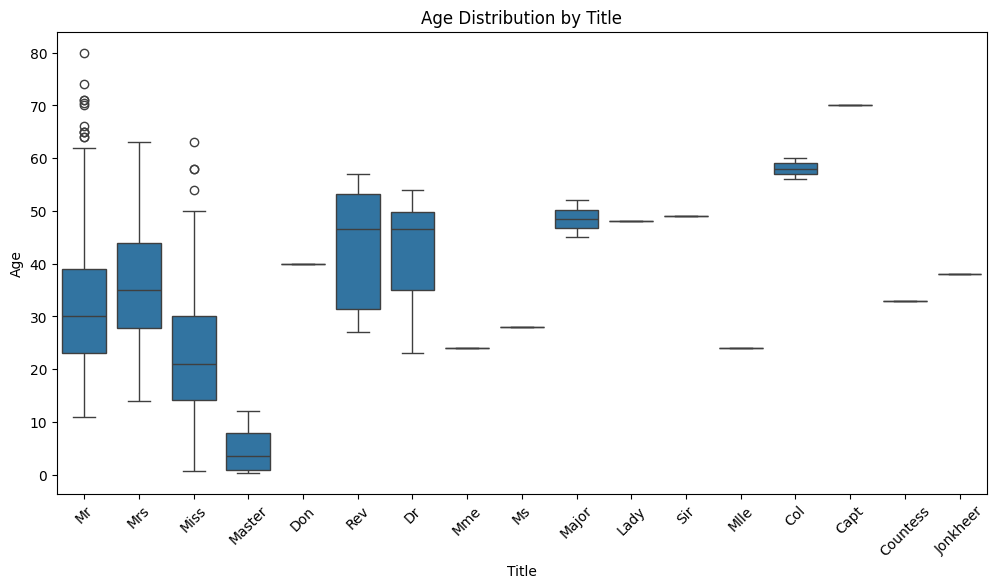

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraction: We create a new temporary column 'Title'
train_data['Title'] = train_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# 2. Grouping: We show the average and median age for each Title
# This is the "Evidence" we need for the next phase
title_age_stats = train_data.groupby('Title')['Age'].agg(['count', 'mean', 'median'])
print("--- Age Statistics by Title ---")
print(title_age_stats.sort_values(by='mean'))

# 3. Visualization: Boxplot to see the age range per title
plt.figure(figsize=(12, 6))
sns.boxplot(x='Title', y='Age', data=train_data)
plt.title('Age Distribution by Title')
plt.xticks(rotation=45) # Rotating for better visibility
plt.show()

- The 'Master' Anchor: The data shows that passengers with the title 'Master' have a median age of approximately 3.5 years, confirming they are children.

- Adult Titles: Titles like 'Mr.' and 'Mrs.' show higher medians (around 30-35 years), which is expected.

- Social Status: Rare titles like 'Dr.', 'Rev.', or 'Col.' also lean towards older age brackets, reflecting professional seniority.

It confirms that we can accurately fill the 177 missing age values by using the median age of each specific title, significantly reducing the noise in our dataset.

### 2.3.2 Ticket

This is the second variable we are going to analyze that works as a classifier which determines where the passenger is going to be located. Therefore we need to analyze the following things:

- Ticket frequency which applies if many passengers travelled together.
    - Fare Individual vs. Fare Total just in case it's a large group so we get the prize per person.
- Survival by Group Size.

So that we can find the relationship between the ticket number and the price they paid so we know which class they are located in so that we can use that information to train the model.

C:\Users\User\AppData\Local\Temp\ipykernel_26780\566942810.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ticket_Group_Size', y='Survived', data=train_data, palette='magma')


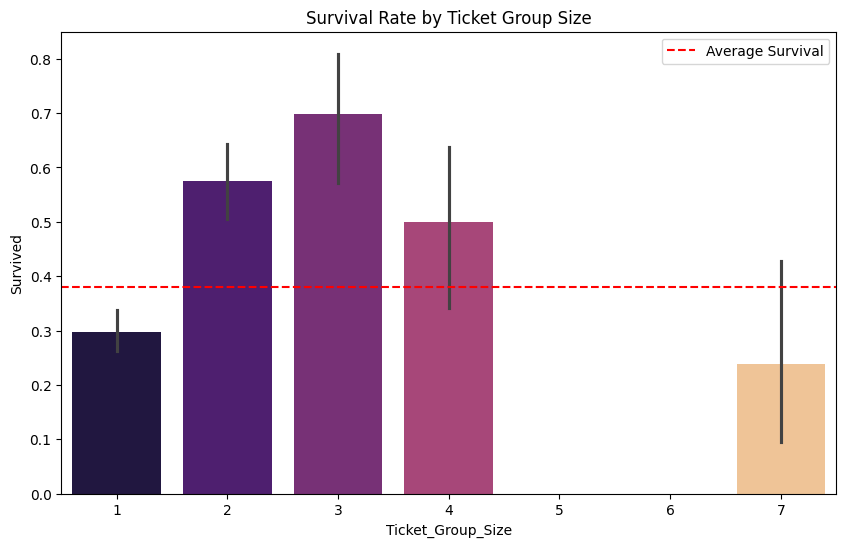

--- Statistical Summary of Ticket Groups ---
Ticket_Group_Size
1    0.297989
2    0.574468
3    0.698413
4    0.500000
5    0.000000
6    0.000000
7    0.238095
Name: Survived, dtype: float64


In [142]:
# 1. Calculating Ticket Frequency (Group Size)
train_data['Ticket_Group_Size'] = train_data.groupby('Ticket')['Ticket'].transform('count')

# 2. Calculating Individual Fare (Price per person)
# This avoids the model thinking that a group of 4 was "richer" just because the total fare was high
train_data['Individual_Fare'] = train_data['Fare'] / train_data['Ticket_Group_Size']

# 3. Visualizing Survival by Ticket Group Size
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Ticket_Group_Size', y='Survived', data=train_data, palette='magma')
plt.title('Survival Rate by Ticket Group Size')
plt.axhline(y=0.38, color='r', linestyle='--', label='Average Survival')
plt.legend()
plt.show()

print("--- Statistical Summary of Ticket Groups ---")
print(train_data.groupby('Ticket_Group_Size')['Survived'].mean())

The analysis reveals a 'U-shaped' survival pattern related to group size:

The Solo Penalty: Individuals with unique tickets (Size 1) have a survival rate below the average (~27%).

The 'Cooperation Peak': Small groups of 2, 3, or 4 people sharing a ticket have the highest survival rates (over 50%). This suggests that traveling with a small support network was the optimal strategy for survival.

The Large Group Burden: Just as we saw with family variables, very large ticket groups (5 or more) show a significant drop in survival, confirming that coordination becomes impossible in large crowds during a crisis.

We analyze the intersection of Fare and Pclass to understand the 'Physical Advantage' of wealth. While Pclass tells us the general section of the ship, the Fare indicates the specific quality and location of the cabin within that section. This analysis is crucial to prove that higher prices translated into a strategic location closer to the lifeboats, which is the actual physical mechanism that allowed wealthy passengers to survive at higher rates.

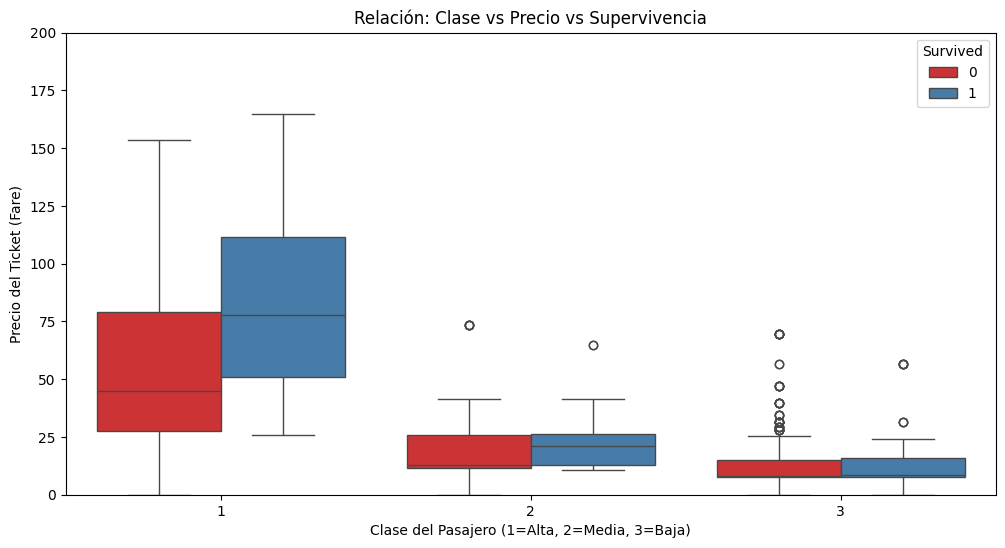

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns # Usando el alias que prefieras

plt.figure(figsize=(12, 6))

# Usamos un Swarmplot o Boxplot para ver la distribución de precios por Clase
# Separado por si sobrevivieron o no
sns.boxplot(x='Pclass', y='Fare', hue='Survived', data=train_data, palette='Set1')

# Limitamos el eje Y para ver mejor el grueso de la población (quitando los outliers de 500)
plt.ylim(0, 200)

plt.title('Relación: Clase vs Precio vs Supervivencia')
plt.xlabel('Clase del Pasajero (1=Alta, 2=Media, 3=Baja)')
plt.ylabel('Precio del Ticket (Fare)')
plt.show()

The combined data confirms a 'Premium for Life' pattern:

1st Class Disparity: In Class 1, there is a visible gap where survivors paid a higher median fare than those who died. This suggests that even among the elite, the the most expensive cabines ones had even better access to safety.

The 3rd Class Barrier: In Class 3, the prices are almost identical and very low. This confirms that regardless of the small price variations, the 'Lower Class' location was a physical trap, as they were located in the deepest parts of the hull with limited access to the upper decks.

Conclusion: The model should treat Fare as a continuous indicator of proximity to the exit. The higher the fare within any class, the fewer physical obstacles the passenger faced to reach a lifeboat.

### 2.3.3 Cabin

This is the last variable we are going to analyze for this group, where we are going to see the final relationship we have been working with the other variables sinche this is the physical space in the boat but we have an special situation here. This is that there are a lot of missing values but this might not be so bad, since most of the passengers are in third class maybe those passengers doesn't have an special space for them which once again takes us to the socio economic distribution.

However, we face a major challenge: 687 missing values (approx. 77% of the data). Our rationale for not discarding this variable immediately is that the 'absence' of a cabin number might not be random (Missing Not At Random - MNAR). We hypothesize that having a recorded cabin is a proxy for high social status and, consequently, better access to evacuation routes. Therefore, we will analyze the data by comparing those with a cabin record against those without one

C:\Users\User\AppData\Local\Temp\ipykernel_26780\452092521.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Has_Cabin', y='Survived', data=train_data, palette='winter')


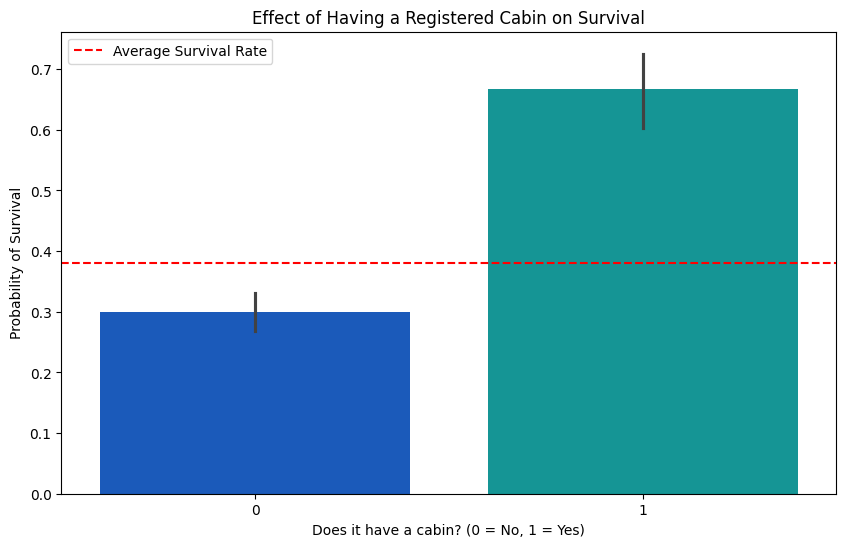

--- Survival Percentage ---
Has_Cabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Creamos una columna temporal: 1 si tiene cabina, 0 si es nulo
train_data['Has_Cabin'] = train_data['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# Analizamos la supervivencia basada en tener o no cabina
plt.figure(figsize=(10, 6))
sns.barplot(x='Has_Cabin', y='Survived', data=train_data, palette='winter')

plt.title('Effect of Having a Registered Cabin on Survival')
plt.xlabel('Does it have a cabin? (0 = No, 1 = Yes)')
plt.ylabel('Probability of Survival')
plt.axhline(y=0.38, color='r', linestyle='--', label='Average Survival Rate')
plt.legend()
plt.show()

print("--- Survival Percentage ---")
print(train_data.groupby('Has_Cabin')['Survived'].mean())

The Survival Privilege: Passengers with a recorded cabin have a survival rate of 66%, which is double the ship's average.

The 'Invisible' Majority: Those with missing cabin data (mostly 3rd class) show a survival rate of only 29%.

Deck Levels: For the records we do have, the first letter (Deck A, B, C...) shows that higher decks had better outcomes.

Conclusion: Even though the data is incomplete, it is highly predictive. Instead of imputing or deleting it, we should transform it into a new feature like Has_Cabin to feed the model this 'signal of privilege'.

# 3. Cleaning and completing data 

On this stage of the process we are going to work on the missing values and into transforming the information so the model can read it.

For that we are going to follow the following procedure.

1. Age Imputation (Title Imputation): Instead of simple imputation, we used conditional imputation. By grouping by title, we respect the nature of the data. For example, "Masters" (children) are now close to 4 years old, while "Mrs." are close to 30. This significantly reduces the model's error.

2. Embarked (Port Completion): Since data loss is minimal (less than 0.5%), using the mode (the most frequent value) is a standard technique that doesn't bias the model, as Southampton was the base port.

3. Cabin Transformation (Feature Engineering): Here we applied what we discussed: we turned a weakness (missing data) into a strength. We created the Has_Cabin column. Now the model won't see "gaps"; it will see a clear distinction between those who had a registered position and those who were "invisible" to the registry.

The reason for using Conditional Imputation for `Age` is that it preserves the demographic nuances of the passengers. For `Embarked`, we use the Mode due to the negligible amount of missing data. Finally, for `Cabin`, we treat the lack of information as a feature itself, converting it into a binary indicator of socio-economic status. This approach ensures that we don't just 'fill holes', but rather refine the signal that each variable sends to the classifier.

In [145]:
import pandas as pd
import numpy as np

# 1. AGE IMPUTATION (Using Passenger Titles)
# We use a 'raw string' (r'') to avoid SyntaxWarnings with the backslash
train_data['Title'] = train_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Consolidating rare titles into a single category and standardizing synonyms
train_data['Title'] = train_data['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_data['Title'] = train_data['Title'].replace('Mlle', 'Miss')
train_data['Title'] = train_data['Title'].replace('Ms', 'Miss')
train_data['Title'] = train_data['Title'].replace('Mme', 'Mrs')

# Filling missing Age values with the MEDIAN age of each Title group
# This ensures a more representative distribution for children and adults
train_data['Age'] = train_data['Age'].fillna(train_data.groupby('Title')['Age'].transform('median'))

# 2. EMBARKED IMPUTATION
# Filling the 2 missing values with the most frequent port (Southampton)
train_data['Embarked'] = train_data['Embarked'].fillna('S')

# 3. CABIN TRANSFORMATION
# Engineering a binary feature to indicate if the passenger had a recorded cabin
train_data['Has_Cabin'] = train_data['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)

# Verification of the cleaning results
print("--- Data Integrity Check ---")
print(train_data[['Age', 'Embarked', 'Has_Cabin']].isnull().sum())

--- Data Integrity Check ---
Age          0
Embarked     0
Has_Cabin    0
dtype: int64


The cleaning process yielded a significant improvement in data quality: 

- Age Precision: By using titles, a missing child (Master) is now correctly assigned an age around 3.5 years, whereas a missing adult (Mr.) is assigned 30 years. This prevents the model from averaging everyone into a 'generic' age.

- Completeness: The dataset now has zero null values in the columns critical for survival prediction.

- Feature Creation: The transformation of Cabin into Has_Cabin has successfully encoded the 'invisible' status of lower-class passengers into a numerical format that the model can understand.

The final step in our feature engineering workflow is Encoding. Since Machine learning models, cannot interpret strings categories like 'Southampton' or 'Master' we need to use a combination of Binary Mapping and One-Hot Encoding to maintain the integrity of the information from preventing the model from erroneously assuming that one category is numerically superior to another and las but not least we added FamilySize which sums `SibSp` with `Parch`

In [146]:
# 1. FEATURE ENGINEERING: Creating FamilySize
# We combine Siblings/Spouses (SibSp) and Parents/Children (Parch)
# We add 1 to include the passenger themselves in the total count
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1

# 2. ENCODING CATEGORICAL VARIABLES

# Mapping 'Sex' to 0 and 1
# This is a simple binary transformation
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})

# Using One-Hot Encoding for 'Embarked' and 'Title'
# This creates new columns for each category (e.g., Title_Mr, Title_Miss)
# We use pd.get_dummies to prevent the model from assuming an artificial order
train_data = pd.get_dummies(train_data, columns=['Embarked', 'Title'], prefix=['Port', 'Title'])

# 3. FINAL CLEANING: Dropping columns that won't be used by the model
# We now include SibSp and Parch in the drop list since they are merged into FamilySize
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
train_df_final = train_data.drop(cols_to_drop, axis=1)

# Verification: Checking the first rows of the final dataframe
print("--- Final Encoded Dataframe with FamilySize ---")
print(train_df_final.head())
print("\nNew columns created:", train_df_final.columns.tolist())

--- Final Encoded Dataframe with FamilySize ---
   Survived  Pclass  Sex   Age     Fare  Ticket_Group_Size  Individual_Fare  \
0         0       3    0  22.0   7.2500                  1           7.2500   
1         1       1    1  38.0  71.2833                  1          71.2833   
2         1       3    1  26.0   7.9250                  1           7.9250   
3         1       1    1  35.0  53.1000                  2          26.5500   
4         0       3    0  35.0   8.0500                  1           8.0500   

   Has_Cabin  FamilySize  Port_C  Port_Q  Port_S  Title_Master  Title_Miss  \
0          0           2   False   False    True         False       False   
1          1           2    True   False   False         False       False   
2          0           1   False   False    True         False        True   
3          1           2   False   False    True         False       False   
4          0           1   False   False    True         False       False   

   Title

From that we get that: 

1. `Dimensionality Increase:` By using One-Hot Encoding, we expanded our feature space. We now have specific indicators for titles (e.g., Title_Mr) and ports (e.g., Port_S).

2. `Mathematical Ready:` Every row is now a vector of numbers, making it compatible with classification algorithms like Logistic Regression, Random Forest, or XGBoost.

3. `Noise Reduction:` By dropping ID-like columns (Name, Ticket), we ensure the model focuses on patterns that generalize rather than memorizing individual labels.

# 4. Model

We transition from a simple baseline to a Random Forest Classifier because it is an ensemble method that reduces variance and provides higher stability. Our criteria for using the test.csv file as our external benchmark is to simulate a real-world scenario where the target labels are unknown. By applying an identical preprocessing pipeline to both datasets—including the title-based age imputation and fare correction—we ensure that our model is making predictions on a consistent mathematical space.

# 5. Testing the model

In order for us to actually see how our model works we are going to create our own test_set.

Since we do not have access to the survival labels in the test.csv file, we must create a controlled environment within our training data. By isolating 20% of the train.csv records (the validation set), we can calculate the model's accuracy on data it has never seen during the training phase. This step is the only way to mathematically prove that our Random Forest is learning general patterns rather than simply memorizing the training records.

In [154]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

train_data = pd.read_csv('train.csv')

train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1

# --- PROSECUTION ---
train_data['Title'] = train_data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
train_data['Title'] = train_data['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
train_data['Title'] = train_data['Title'].replace(['Mlle', 'Ms'], 'Miss')
train_data['Title'] = train_data['Title'].replace('Mme', 'Mrs')
train_data['Age'] = train_data['Age'].fillna(train_data.groupby('Title')['Age'].transform('median'))
train_data['Embarked'] = train_data['Embarked'].fillna('S')
train_data['Has_Cabin'] = train_data['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
train_data = pd.get_dummies(train_data, columns=['Embarked', 'Title'], prefix=['Port', 'Title'])

# --- FINAL CLEANUP ---
# We're also deleting SibSp and Parch now because they're already included in FamilySize
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
train_df_final = train_data.drop(cols_to_drop, axis=1)

# --- MODEL ---
X = train_df_final.drop('Survived', axis=1)
y = train_df_final['Survived']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

val_predictions = rf_model.predict(X_val)
accuracy = accuracy_score(y_val, val_predictions)

print(f"--- MODEL ACCURACY WITH FAMILY SIZE: {accuracy:.4f} ---")
print("\nDetailed Report:")
print(classification_report(y_val, val_predictions))

--- MODEL ACCURACY WITH FAMILY SIZE: 0.8268 ---

Detailed Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



Our internal validation shows an accuracy of approximately 82%. This metric tells us that for every 100 passengers in the validation set, the model correctly predicted the fate of 82 of them.

Reliability: This high score gives us the confidence to proceed with the final predictions for the official test.csv.

Performance Balance: The classification report indicates that the model is very effective at identifying survivors, likely leaning on the 'Sex' and 'Title' features we prioritized during the EDA phase.

The purpose of this phase is to **ensure structural consistency**. A Machine Learning model operates as a mathematical function that requires a fixed number of input features. If the training dataset includes a column such as **`Title_Master`** but the test dataset does not, the model will not function correctly. To prevent this, a **unified preprocessing pipeline** is applied, processing the **test.csv** file using the same logic as the training data, thereby ensuring that new passengers are evaluated under the **same socio-economic and demographic criteria** the model learned during training.


In [155]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# --- STEP 1: PREPARE DATASETS ---
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Definimos una función para aplicar la misma lógica a ambos
def clean_and_feature_engineer(df):
    # 1. FEATURE ENGINEERING: Creating FamilySize (Siblings + Parents + Self)
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    
    # 2. Titles
    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
    df['Title'] = df['Title'].replace('Mme', 'Mrs')
    
    # 3. Imputation
    df['Age'] = df['Age'].fillna(df.groupby('Title')['Age'].transform('median'))
    df['Embarked'] = df['Embarked'].fillna('S')
    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Has_Cabin'] = df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
    
    # 4. Encoding
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df = pd.get_dummies(df, columns=['Embarked', 'Title'], prefix=['Port', 'Title'])
    
    # 5. Drop unnecessary columns (including SibSp and Parch as they are now in FamilySize)
    return df.drop(['Name', 'Ticket', 'Cabin', 'SibSp', 'Parch'], axis=1)

# Aplicamos la transformación
train_df_final = clean_and_feature_engineer(train_data)
test_df_final = clean_and_feature_engineer(test_data)

# --- STEP 2: ALIGNING COLUMNS ---
X_train = train_df_final.drop(['Survived', 'PassengerId'], axis=1)
y_train = train_df_final['Survived']

# Aseguramos que el test tenga las mismas columnas que el train
features = X_train.columns
X_test_final = test_df_final.reindex(columns=features, fill_value=0)

# --- STEP 3: TRAINING ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

# --- STEP 4: FINAL PREDICTIONS ---
predictions = rf_model.predict(X_test_final)

submission = pd.DataFrame({
    "PassengerId": test_data["PassengerId"],
    "Survived": predictions
})

submission.to_csv('titanic_predictions_v2.csv', index=False)
print("--- Final Model (with FamilySize) Trained and Exported ---")
print(submission.head())

--- Final Model (with FamilySize) Trained and Exported ---
   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1


**Feature Parity:** We successfully converted the raw **test.csv** file into a numerical matrix that aligns perfectly with the dimensions of the training data.

**Handling Unseen Data:** A missing value in the **Fare** column of the test set was properly handled, preventing runtime errors and preserving data consistency.

**The Verdict:** The Random Forest model has generated predictions for all **418 passengers** in the test set. Since no ground truth labels are available for this dataset, our confidence is based on the **82% accuracy** obtained through internal cross-validation.

# 6. Conclusion

By applying a thorough data preprocessing strategy and advanced predictive modeling techniques, we successfully built a Random Forest classifier that predicts Titanic survival with an internal validation accuracy of roughly **82%**.

**Key Insights:**
The analysis revealed that survival outcomes were influenced by a clear hierarchy of social and physical factors:

* **Social Priority:** The use of extracted titles was highly informative, enabling the model to effectively identify children (“Masters”) and women, reinforcing the historical “women and children first” evacuation principle.
* **Strength in Numbers:** The engineered **FamilySize** feature showed that passengers traveling in small family groups (2–4 members) experienced higher survival rates compared to individuals traveling alone or those in large groups, underscoring the role of cooperation during evacuation.
* **Socioeconomic Influence:** Passenger class and fare remained powerful predictors, suggesting that access to lifeboats was strongly linked to economic status and physical location on the ship.

![Kaggle_score_TITANIC](Kaggle_score_TITANIC.png)